In [1]:
# --- Offline mock of the `anthropic` package -------------------------------
# Flip this to False to use the real Anthropic API (requires ANTHROPIC_API_KEY).
USE_MOCK_ANTHROPIC_API = True

if USE_MOCK_ANTHROPIC_API:
    import sys
    import types
    import uuid
    import random
    import re
    import hashlib
    import json

    # --- Generic reply generation (no topic-specific canned answers) --------
    # Everything below is derived only from the request itself (the messages,
    # system prompt, temperature, max_tokens) — nothing here is written for a
    # specific prompt, so this works the same for any notebook/any question.

    _STOPWORDS = {
        "what", "this", "that", "with", "from", "have", "about", "your",
        "just", "write", "generate", "please", "which", "would", "could",
        "should", "short", "very", "sentence", "description", "the", "and",
        "for", "are", "was", "were", "been", "define", "explain", "tell",
        "give", "make", "create", "provide", "using", "sample", "each", "one",
    }

    _OPENERS = [
        "Here's a placeholder response",
        "This is a mocked reply",
        "Simulated output",
        "Stand-in text",
        "Generated placeholder",
        "Mock reply",
    ]
    _CONNECTORS = [
        "touching on",
        "loosely related to",
        "in the general area of",
        "standing in for a real answer about",
        "referencing",
        "sketching out something about",
    ]

    def _last_user_text(messages):
        for m in reversed(messages):
            if m.get("role") == "user":
                content = m.get("content", "")
                return content if isinstance(content, str) else str(content)
        return ""

    def _last_assistant_prefill(messages):
        # If the last message is an assistant turn, it's a prefill (e.g. "```json")
        if messages and messages[-1].get("role") == "assistant":
            content = messages[-1].get("content", "")
            return content if isinstance(content, str) else str(content)
        return ""

    def _extract_keywords(text, n=4):
        words = re.findall(r"[A-Za-z']{4,}", text.lower())
        seen = []
        for w in words:
            if w not in _STOPWORDS and w not in seen:
                seen.append(w)
        return seen[:n] or ["this"]

    def _seeded_rng(*parts):
        h = hashlib.sha256("||".join(str(p) for p in parts).encode()).hexdigest()
        return random.Random(int(h[:16], 16))

    def _generic_prose(rng, keywords, target_words):
        kw = ", ".join(keywords)
        sentence = f"{rng.choice(_OPENERS)} {rng.choice(_CONNECTORS)} {kw}."
        while len(sentence.split()) < target_words:
            sentence += f" {rng.choice(_OPENERS)} {rng.choice(_CONNECTORS)} {rng.choice(keywords)}."
        return sentence

    _CODE_FENCE_RE = re.compile(r"```\s*([a-zA-Z0-9_+-]*)\s*$")

    def _generate_mock_reply(messages, system=None, temperature=1.0, max_tokens=1000):
        messages = messages or []
        user_text = _last_user_text(messages)
        keywords = _extract_keywords(user_text)

        temperature = 1.0 if temperature is None else temperature
        seed_parts = [user_text, system, len(messages)]
        # Low temperature -> deterministic (same seed every call, like a real
        # low-temp model). Higher temperature -> inject real entropy so
        # repeated calls with the same prompt actually vary, like the API.
        if temperature > 0.3:
            seed_parts.append(random.random())
        rng = _seeded_rng(*seed_parts)

        # Structural pattern: an assistant-turn prefill ending in a code fence
        # (```json, ```python, ```bash, bare ```, ...). This is a *format*
        # detector, not a topic-specific answer — it works for any language
        # tag or schema, derived only from the user's own keywords.
        prefill = _last_assistant_prefill(messages)
        fence_match = _CODE_FENCE_RE.search(prefill)
        if fence_match:
            lang = fence_match.group(1).lower()
            if lang == "json":
                obj = {kw: f"placeholder_value_{i}" for i, kw in enumerate(keywords)}
                return json.dumps(obj, indent=2) + "\n```"
            comment = "//" if lang in ("js", "javascript", "ts", "typescript", "java", "c", "cpp") else "#"
            body = "\n".join(f"{comment} mocked step involving {kw}" for kw in keywords)
            return f"{body}\n```"

        # Length is independent of max_tokens — a real response's length
        # doesn't scale with the safety-net cutoff either (see the notebook's
        # own note on max_tokens being a cutoff, not a target).
        target_words = rng.randint(12, 30)
        text = _generic_prose(rng, keywords, target_words)

        # Still respect max_tokens as a hard cutoff, same as the real API.
        approx_max_chars = max(1, max_tokens) * 4
        if len(text) > approx_max_chars:
            text = text[:approx_max_chars].rsplit(" ", 1)[0] + "..."
        return text

    def _apply_stop_sequences(text, stop_sequences):
        if stop_sequences:
            for seq in stop_sequences:
                idx = text.find(seq)
                if idx != -1:
                    return text[:idx]
        return text

    # --- API-shaped plumbing (mirrors the real SDK's object shapes) ---------

    class _MockUsage:
        def __init__(self, text):
            self.input_tokens = max(1, len(text) // 4)
            self.output_tokens = max(1, len(text) // 4)

    class _MockTextBlock:
        def __init__(self, text):
            self.type = "text"
            self.text = text

    class _MockMessage:
        def __init__(self, text, model, stop_reason="end_turn"):
            self.id = f"msg_mock_{uuid.uuid4().hex[:12]}"
            self.type = "message"
            self.role = "assistant"
            self.model = model
            self.content = [_MockTextBlock(text)]
            self.stop_reason = stop_reason
            self.stop_sequence = None
            self.usage = _MockUsage(text)

        def __repr__(self):
            return f"_MockMessage(model={self.model!r}, text={self.content[0].text[:60]!r}...)"

    class _MockDelta:
        def __init__(self, text):
            self.type = "text_delta"
            self.text = text

    class _MockStreamEvent:
        def __init__(self, event_type, delta=None):
            self.type = event_type
            self.delta = delta

        def __repr__(self):
            return f"_MockStreamEvent(type={self.type!r})"

    def _chunk_text(text, chunk_size=12):
        words = text.split(" ")
        buf = ""
        for w in words:
            buf += w + " "
            if len(buf) >= chunk_size:
                yield buf
                buf = ""
        if buf:
            yield buf

    def _mock_stream_events(text):
        yield _MockStreamEvent("message_start")
        for chunk in _chunk_text(text):
            yield _MockStreamEvent("content_block_delta", delta=_MockDelta(chunk))
        yield _MockStreamEvent("message_stop")

    class _MockMessageStreamManager:
        def __init__(self, text, model):
            self._text = text
            self._final_message = _MockMessage(text, model)

        def __enter__(self):
            return self

        def __exit__(self, exc_type, exc_val, exc_tb):
            return False

        @property
        def text_stream(self):
            for chunk in _chunk_text(self._text):
                yield chunk

        def __iter__(self):
            return iter(_mock_stream_events(self._text))

        def get_final_message(self):
            return self._final_message

    class _MockMessages:
        def create(self, *, model, max_tokens=1000, messages=None, system=None,
                   temperature=1.0, stop_sequences=None, stream=False, **kwargs):
            text = _generate_mock_reply(messages, system=system, temperature=temperature, max_tokens=max_tokens)
            text = _apply_stop_sequences(text, stop_sequences)
            if stream:
                return _mock_stream_events(text)
            return _MockMessage(text, model)

        def stream(self, *, model, max_tokens=1000, messages=None, system=None,
                   temperature=1.0, stop_sequences=None, **kwargs):
            text = _generate_mock_reply(messages, system=system, temperature=temperature, max_tokens=max_tokens)
            text = _apply_stop_sequences(text, stop_sequences)
            return _MockMessageStreamManager(text, model)

    class _MockAnthropic:
        def __init__(self, *args, **kwargs):
            self.messages = _MockMessages()

    # Register a fake `anthropic` module so `from anthropic import Anthropic`
    # (later in this notebook) picks up the mock instead of the real package.
    _mock_module = types.ModuleType("anthropic")
    _mock_module.Anthropic = _MockAnthropic
    sys.modules["anthropic"] = _mock_module

    print("Mock Anthropic API enabled — no network calls or API key required.")
else:
    print("Mock disabled — using the real anthropic package.")
# ----------------------------------------------------------------------

Mock Anthropic API enabled — no network calls or API key required.


# 1. Prompt Evalutation

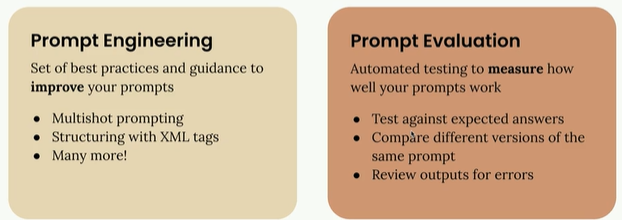

1. **Prompt engineering** gives you techniques for writing better prompts 
2. **Prompt evaluation** helps you measure how well those prompts actually work.

We're going to investigate drafting a really good prompt for use in serious applications.

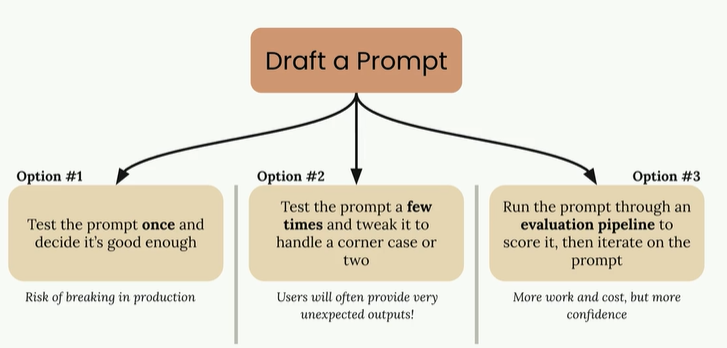

Run your prompt through an evalutaion pipeline to see how well it is performing. 

# 2. Prompt Evaluation Workflow

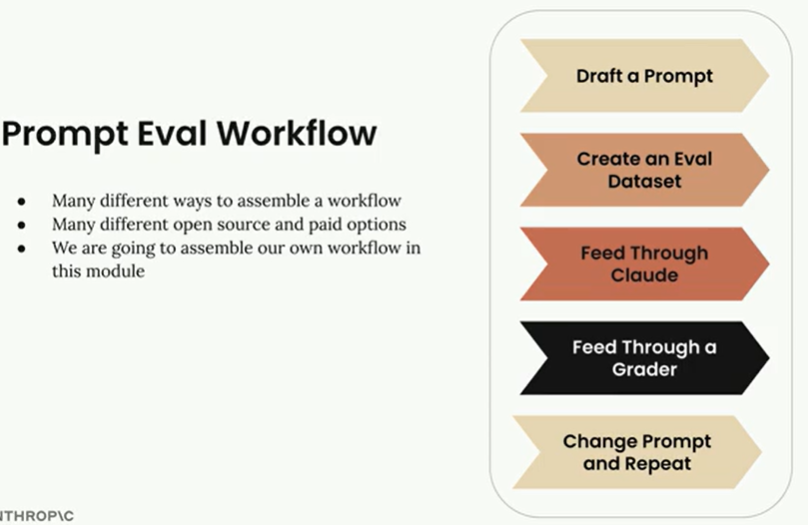

##### 1. Initial Prompt Draft


In [2]:
prompt = f"""
Please answer the user's question: {question}
"""

NameError: name 'question' is not defined

#### 2. Evaluation Dataset 
* Contains questions that we will merge with our prompt.
* Can be assembled by hand or generated by Claude

#### 3. Feed Through Claude
We take all of the evaluation prompts that we have in our evaluation dataset and give them to Claude.

#### 4. Feed Through a Grader

1. We pair each prompt with its output and then assign it a 'grade' by putting it through a 'grader'. There are a few different kinds of graders - but we'll talk about that later.
2. Then we **average** the graded scores. 

This tells us how well the original prompt performed.

#### 5. Change Prompt and Repeat
We refine the model by adding refinements to the original prompt.
We can maybe now change it to:

In [ ]:
prompt = f"""
Please answer the user's question: {question}

Answer with ample details.
"""


#### 6. Prompt Scoring
After running and tuning the prompt again and again, we can rank each prompt's performance with its average graded scores.

# 3. Generating Test Datasets

> Goal: Write a prompt that will assist users in writing Python code, JSON config, or Regular expressions focuesed on AWS-specific use cases.
* **Input**: User will request code for a specific task
* **Output**: Python, JSON, or a regular expression without any explanation.

In [ ]:
#Prompt Version 1
prompt = f"""
Please provide a solution to the following task: 
{task}
"""

In [ ]:
# Load env variables and create client
from dotenv import load_dotenv
from anthropic import Anthropic

load_dotenv()

client = Anthropic()
model = "claude-haiku-4-5"

In [ ]:
# Helper functions
def add_user_message(messages, text):
    user_message = {"role": "user", "content": text}
    messages.append(user_message)


def add_assistant_message(messages, text):
    assistant_message = {"role": "assistant", "content": text}
    messages.append(assistant_message)


def chat(messages, system=None, temperature=1.0, stop_sequences=[]):
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
        "temperature": temperature,
        "stop_sequences": stop_sequences,
    }

    if system:
        params["system"] = system

    message = client.messages.create(**params)
    return message.content[0].text

In [ ]:
import json


def generate_dataset():
    prompt = """
Generate a evaluation dataset for a prompt evaluation. The dataset will be used to evaluate prompts
that generate Python, JSON, or Regex specifically for AWS-related tasks. Generate an array of JSON objects,
each representing task that requires Python, JSON, or a Regex to complete.

Example output:
```json
[
    {
        "task": "Description of task",
    },
    ...additional
]
```

* Focus on tasks that can be solved by writing a single Python function, a single JSON object, or a regular expression.
* Focus on tasks that do not require writing much code

Please generate 3 objects.
"""

# ★ 4. Running the Eval

The evaluation process follows a clear workflow: we take our dataset of test cases, combine each one with our prompt template, send it to Claude for processing, and then evaluate the output using a grader system.

#### Building the Core Functions
The evaluation pipeline consists of three main functions, each with a specific responsibility. Let's start with the simplest one - the function that handles individual prompts.

#### `Run_prompt()`
The `run_prompt` function take a test case and merges it with our prompt template.

In [ ]:
def run_prompt(test_case):
    """Merges the prompt and test case input, then returns the result"""
    prompt = f"""
Please solve the following task:

{test_case["task"]}
"""
    
    messages = []
    add_user_message(messages, prompt)
    output = chat(messages)
    return output

#### `run_next_case()`
The `run_text_case` function orchestrares running a single test case and grading the results.

In [ ]:
def run_test_case(test_case):
    """Calls run_prompt, then grades the result"""
    output = run_prompt(test_case)
    
    # TODO - Grading
    score = 10
    
    return {
        "output": output,
        "test_case": test_case,
        "score": score
    }

For now, we're using a hardcoded score of 10. The grading logic is where we'll spend significant time in upcoming sections, but this placeholder lets us test the overall pipeline.

#### `run_eval()`
The `run_eval` function coordinates the entire evalutation process.

In [ ]:
def run_eval(dataset):
    """Loads the dataset and calls run_test_case with each case"""
    results = []
    
    for test_case in dataset:
        result = run_test_case(test_case)
        results.append(result)
    
    return results

This function processes every test case in our dataset and collects all the results into a single list.

#### Running the Evaluation
To execute our evaluation pipeline, we load our dataset and run it through our functions. 
The first time you run this, expect it to take some time - even with Claude Haiku, it can take around 30 seconds to process a full dataset. We'll cover optimization techniques later.

In [1]:
with open("dataset.json", "r") as f:
    dataset = json.load(f)

results = run_eval(dataset)

FileNotFoundError: [Errno 2] No such file or directory: 'dataset.json'

#### Examining the Results

The evaluation returns a structured JSON array where each object represents one test case result:

In [ ]:
print(json.dumps(results, indent=2))

Each result contains three key pieces of information:

1. **output:** The complete response from Claude
2. **test_case:** The original test case that was processed
3. **score:** The evaluation score (currently hardcoded)

#### What We've Accomplished
At this point, we've successfully built the core evaluation pipeline. We can take our dataset, process it through Claude, and collect structured results. The major missing piece is the grading system - **that hardcoded score of 10 needs to be replaced with actual evaluation logic.**

This pipeline represents the foundation of most AI evaluation systems. While it may seem simple, you've just built the majority of what an eval pipeline actually does. The complexity comes in the details - better prompts, sophisticated grading, and performance optimizations.

Next, we'll dive into the critical topic of graders, which will transform our hardcoded scores into meaningful evaluations of Claude's performance.

# 5. Model Based Grading

There are three main approaches to grading model outputs.
* **Code graders**  Programmatically evaluate outputs using custom logic
* **Model graders** - Use another AI model to assess the quality
* **Human graders** - Have people manually review and score outputs

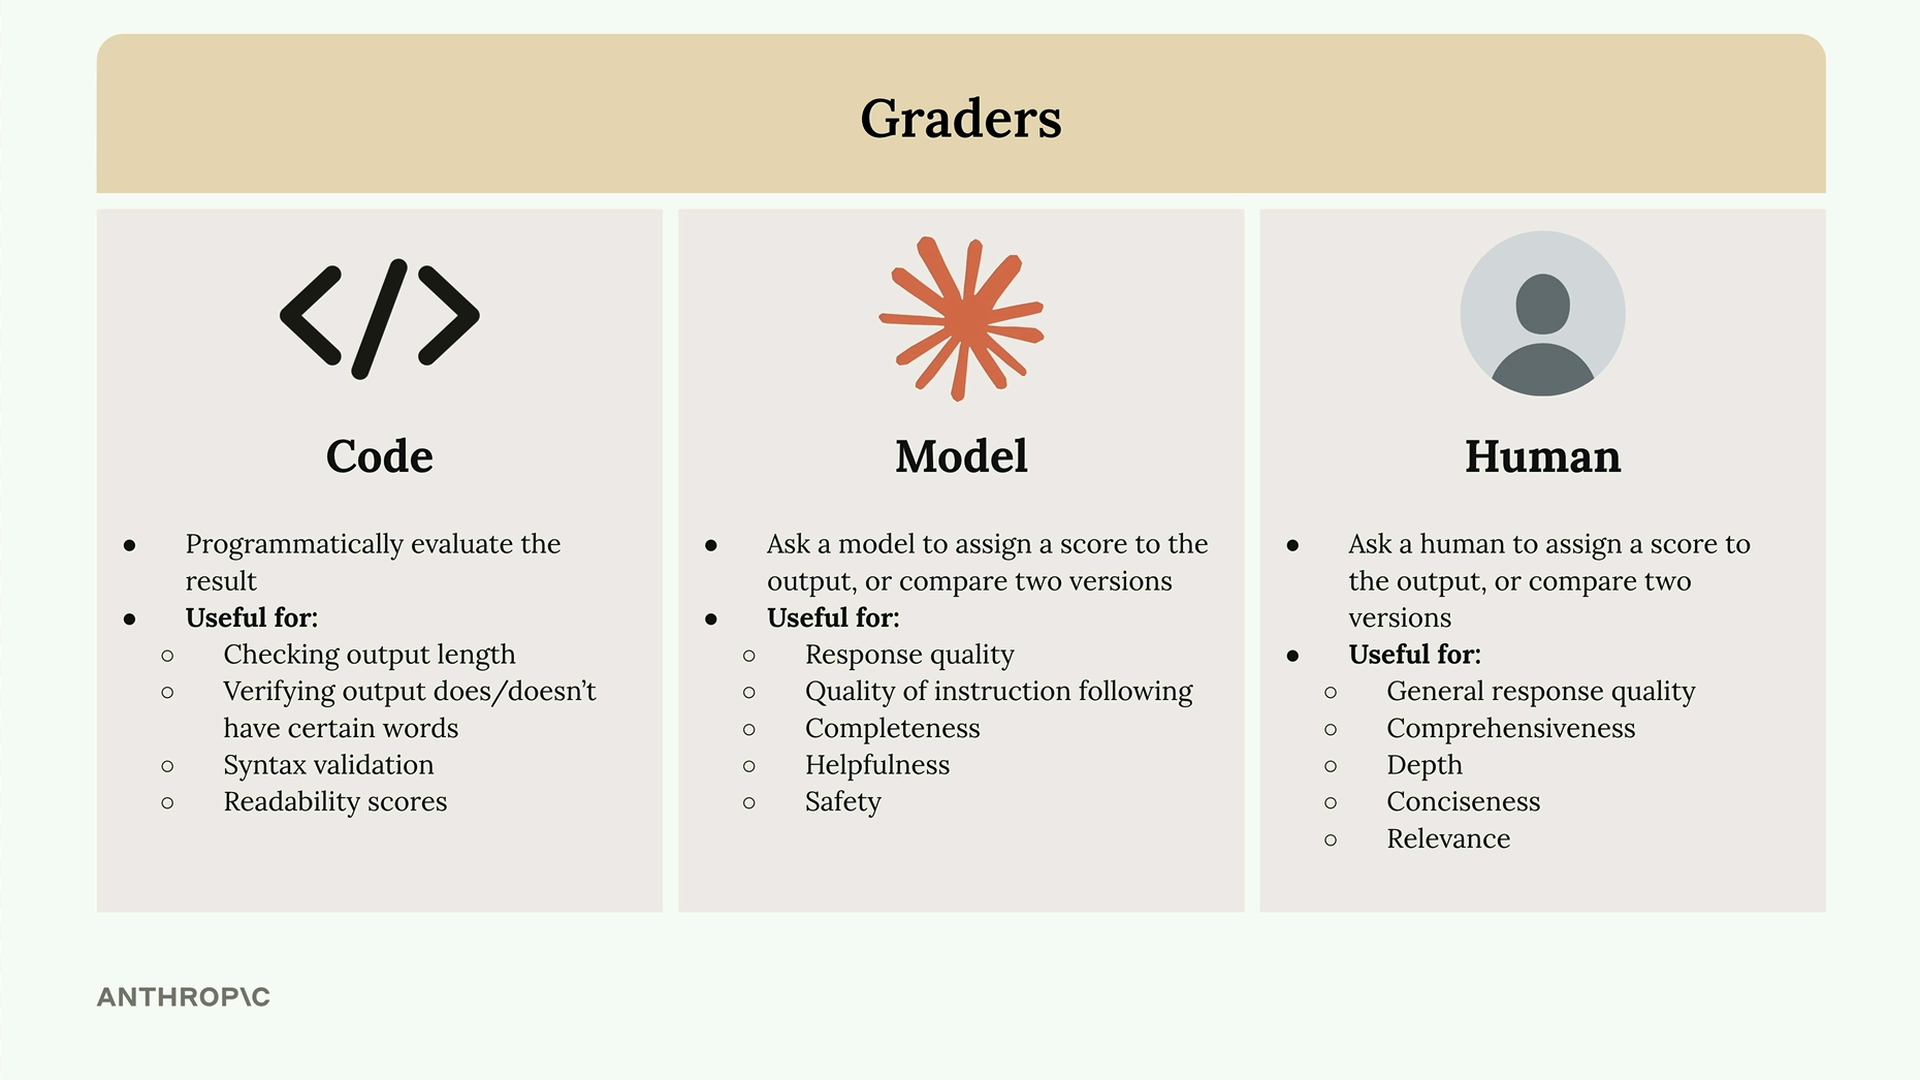

#### Code Graders

Code graders let you implement any programmatic check you can imagine. Common uses include:

* Checking output length
* Verifying output does/doesn't have certain words
* Syntax validation for JSON, Python, or regex
* Readability scores
The only requirement is that your code returns some usable signal - usually a number between 1 and 10.

#### Model Graders
Model graders feed your original output into another API call for evaluation. This approach offers tremendous flexibility for assessing:

* Response quality
* Quality of instruction following
* Completeness
* Helpfulness
* Safety

#### Human Graders
Human graders provide the most flexibility but are time-consuming and tedious. They're useful for evaluating:

* General response quality
* Comprehensiveness
* Depth
* Conciseness
* Relevance

### Defining Evaluation Criteria
Before implementing any grader, you need clear evaluation criteria. For a code generation prompt, you might focus on...

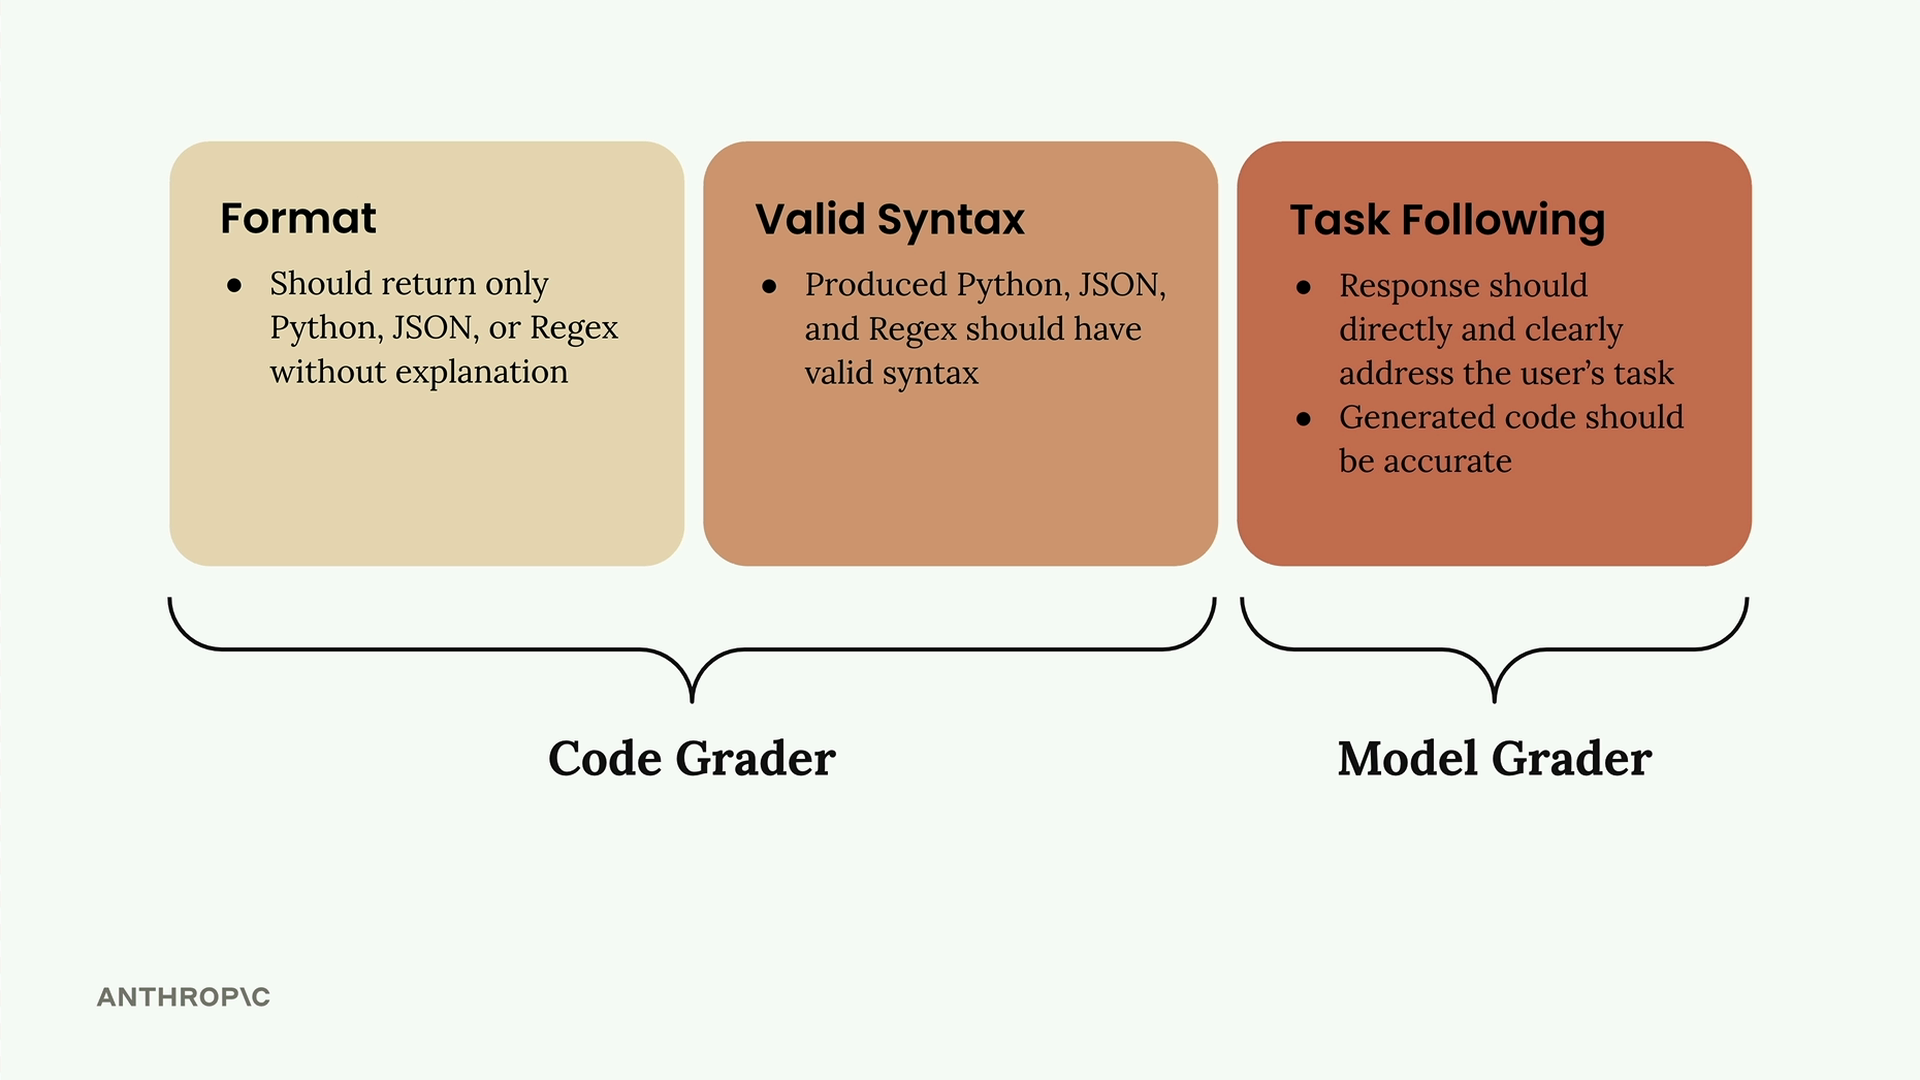

The first two criteria work well with code graders, while task following is better suited for model graders due to their flexibility.

### Implementing a Model Grader (Using another AI model to assess performance)

Here's how to build a model grader function:

In [ ]:
def grade_by_model(test_case, output):
    # Create evaluation prompt
    eval_prompt = """
    You are an expert code reviewer. Evaluate this AI-generated solution.
    
    Task: {task}
    Solution: {solution}
    
    Provide your evaluation as a structured JSON object with:
    - "strengths": An array of 1-3 key strengths
    - "weaknesses": An array of 1-3 key areas for improvement  
    - "reasoning": A concise explanation of your assessment
    - "score": A number between 1-10
    """
    
    messages = []
    add_user_message(messages, eval_prompt)
    add_assistant_message(messages, "```json")
    
    eval_text = chat(messages, stop_sequences=["```"])
    return json.loads(eval_text)

The key insight is **asking for strengths, weaknesses, and reasoning alongside the score**. **Without this context, models tend to default to middling scores around 6.**

### Integrating grading into Your workflow
Update your test case runner to call the grader:



In [ ]:
def run_test_case(test_case):
    output = run_prompt(test_case)
    
    # Grade the output
    model_grade = grade_by_model(test_case, output)
    score = model_grade["score"]
    reasoning = model_grade["reasoning"]
    
    return {
        "output": output, 
        "test_case": test_case, 
        "score": score,
        "reasoning": reasoning
    }

Finally, calculate an average score across all test cases:

In [ ]:
from statistics import mean

def run_eval(dataset):
    results = []
    
    for test_case in dataset:
        result = run_test_case(test_case)
        results.append(result)
    
    average_score = mean([result["score"] for result in results])
    print(f"Average score: {average_score}")
    
    return results

This gives you an objective metric to track as you iterate on your prompt. While model graders can be somewhat capricious, they provide a consistent baseline for measuring improvements.

* See `Prompt Evaluation.ipynb` for the complete code and context.    

# 6. Code Based Grading
When evaluating AI models that generate code, you need more than just checking if the response makes sense. You also need to verify that the generated code actually has valid syntax and follows the correct format. 

Code grading validates two key aspects of AI-generated responses. The first two criteria are handled by the code grader, while task following is evaluated by the model grader. Together, they provide a comprehensive evaluation.

1. **Format** - The response should return only the requested code type (Python, JSON, or Regex) without explanations
2. **Valid Syntax** - The generated code should actually parse correctly as the intended language
3. **Task Following** - The response should directly address what was asked and be accurate

#### Syntax Validation Functions

In [ ]:
def validate_json(text):
    try:
        json.loads(text.strip())
        return 10
    except json.JSONDecodeError:
        return 0

def validate_python(text):
    try:
        ast.parse(text.strip())
        return 10
    except SyntaxError:
        return 0

def validate_regex(text):
    try:
        re.compile(text.strip())
        return 10
    except re.error:
        return 0

#### Dataset Format Requirements

For the code grader to know which validator to use, your test cases need to specify the expected output format. You can update your dataset generation prompt to automatically include this format field by adding it to the example output structure.

In [ ]:
{
    "task": "Create a Python function to validate an AWS IAM username",
    "format": "python"
}

#### Improving Prompt Clarity
To get better results from your AI model, make your prompt instructions more specific about the expected output format:

In [ ]:
* Respond only with Python, JSON, or a plain Regex
* Do not add any comments or commentary or explanation

You can also use a pre-filled assistant message with code blocks to encourage the model to return just the raw code. This tells Claude to start generating code content without having to specify whether it's Python, JSON, or Regex ahead of time.

In [ ]:
add_assistant_message(messages, "```code")

### Combining Scores
The final step is merging the model grader score with the code grader score. A simple approach is to take the **average**:

In [ ]:
model_grade = grade_by_model(test_case, output)
model_score = model_grade["score"]
syntax_score = grade_syntax(output, test_case)

score = (model_score + syntax_score) / 2

This gives equal weight to both content quality and technical correctness. You might **adjust these weights** based on what matters more for your specific use case.


# 7. Exercise on Prompt Evaluations
